In [ ]:
# loading our libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# loading Datasets
df = pd.read_csv("data_jobs.csv")

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)
df_da_remote_exploded = df_da_remote.explode('job_skills')

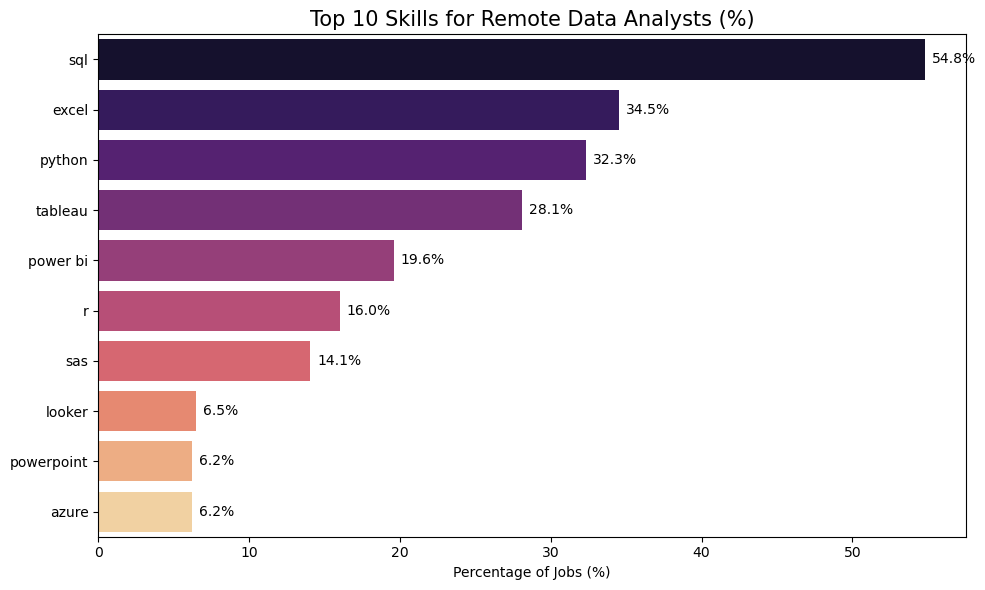

In [ ]:
#Data Filtering
df_da_remote = df[(df['job_title_short'] == 'Data Analyst') & 
                  (df['job_work_from_home'] == True)].copy()

total_jobs = len(df_da_remote)
df_da_remote = df_da_remote.dropna(subset=['job_skills'])
skill_stats = df_da_remote_exploded['job_skills'].value_counts().head(10).reset_index()
skill_stats.columns = ['skill', 'count']
skill_stats['percentage'] = (skill_stats['count'] / total_jobs) * 100

#Graph Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=skill_stats, x='percentage', y='skill', hue='skill', palette='magma', legend=False)
plt.title('Top 10 Skills for Remote Data Analysts (%)', fontsize=15)
plt.xlabel('Percentage of Jobs (%)')
plt.ylabel('')

for i, p in enumerate(ax.patches):
    ax.annotate(f'{skill_stats.percentage.iloc[i]:.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()